In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('_cancer_dataset_uae.csv')  # adjust path if needed
df.head()

,Age,Gender,Nationality,Emirate,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height
0,69,Female,Emirati,Umm Al Quwain,Liver,II,Radiation,12/4/2020,Sheikh Khalifa Hospital,Dr. VO41,Recovered,NaN,NaN,Non-Smoker,NaN,European,61,157
1,32,Male,Emirati,Umm Al Quwain,Leukemia,III,Surgery,11/5/2015,Dubai Hospital,Dr. SM31,Recovered,NaN,NaN,Smoker,NaN,South Asian,80,175
2,89,Male,Emirati,Abu Dhabi,Liver,III,Radiation,8/3/2018,Zayed Military Hospital,Dr. BC7,Under Treatment,NaN,NaN,Non-Smoker,NaN,South Asian,50,175
3,78,Female,Emirati,Abu Dhabi,Lung,III,Radiation,3/13/2022,Cleveland Clinic Abu Dhabi,Dr. TC14,Recovered,NaN,NaN,Former Smoker,NaN,African,44,155
4,38,Female,Emirati,Fujairah,Pancreatic,II,Chemotherapy,2/29/2020,Sheikh Khalifa Hospital,Dr. YS37,Recovered,NaN,NaN,Former Smoker,NaN,East Asian,101,160


In [7]:
# Drop target and ID columns
X = df.drop(columns=['Cancer_Stage'])  # adjust column name
X = pd.get_dummies(X, drop_first=True)  # convert categoricals
X.head()

,Age,Weight,Height,Gender_Male,Gender_Other,Nationality_Expatriate,Emirate_Ajman,Emirate_Dubai,Emirate_Fujairah,Emirate_Ras Al Khaimah,...,Death_Date_9/9/2024 0:00,Cause_of_Death_Complications,Smoking_Status_Non-Smoker,Smoking_Status_Smoker,Comorbidities_Diabetes,Comorbidities_Hypertension,Ethnicity_Arab,Ethnicity_East Asian,Ethnicity_European,Ethnicity_South Asian
0,69,61,157,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,32,80,175,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,89,50,175,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,78,44,155,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,38,101,160,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

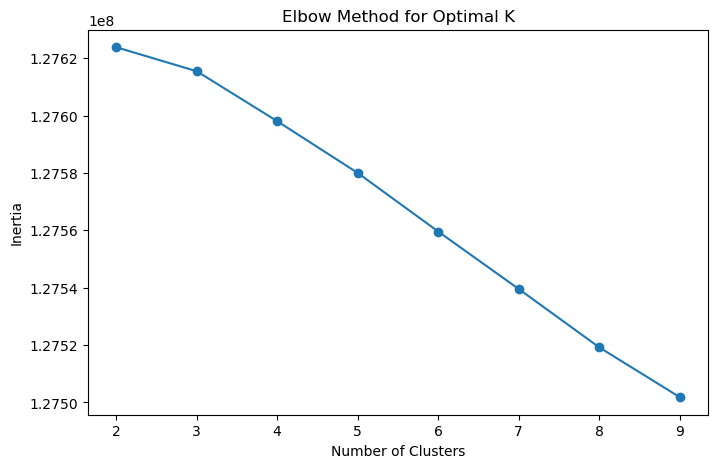

In [11]:
inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)  # change 3 as needed
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,Age,Gender,Nationality,Emirate,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height,Cluster
0,69,Female,Emirati,Umm Al Quwain,Liver,II,Radiation,12/4/2020,Sheikh Khalifa Hospital,Dr. VO41,Recovered,NaN,NaN,Non-Smoker,NaN,European,61,157,2
1,32,Male,Emirati,Umm Al Quwain,Leukemia,III,Surgery,11/5/2015,Dubai Hospital,Dr. SM31,Recovered,NaN,NaN,Smoker,NaN,South Asian,80,175,2
2,89,Male,Emirati,Abu Dhabi,Liver,III,Radiation,8/3/2018,Zayed Military Hospital,Dr. BC7,Under Treatment,NaN,NaN,Non-Smoker,NaN,South Asian,50,175,2
3,78,Female,Emirati,Abu Dhabi,Lung,III,Radiation,3/13/2022,Cleveland Clinic Abu Dhabi,Dr. TC14,Recovered,NaN,NaN,Former Smoker,NaN,African,44,155,2
4,38,Female,Emirati,Fujairah,Pancreatic,II,Chemotherapy,2/29/2020,Sheikh Khalifa Hospital,Dr. YS37,Recovered,NaN,NaN,Former Smoker,NaN,East Asian,101,160,2


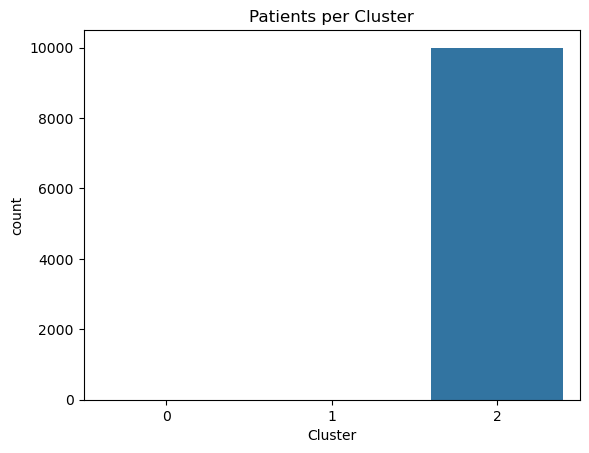

,Age,Weight,Height
Cluster,,,
0,63.000000,98.000000,171.000000
1,66.000000,81.000000,170.000000
2,53.537508,69.546009,169.347269


In [15]:
# Count of samples per cluster
sns.countplot(x='Cluster', data=df)
plt.title('Patients per Cluster')
plt.show()

# Mean values of features by cluster
df.groupby('Cluster').mean(numeric_only=True)

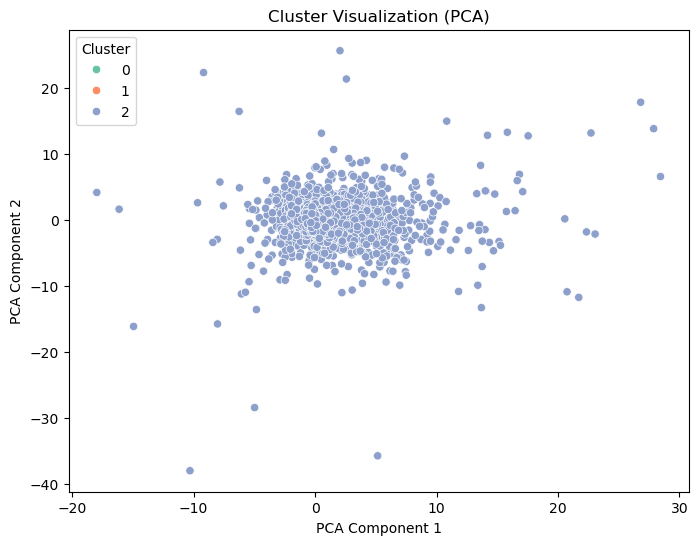

In [17]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=df['Cluster'], palette='Set2')
plt.title('Cluster Visualization (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [21]:
import os
os.makedirs('figures', exist_ok=True)

In [23]:
plt.savefig('figures/elbow_method.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>